# Model discrepancy with a Gaussian-process term

A linear model is fit to data drawn from a *mildly non-linear* truth. The model
is structurally wrong, so a plain fit leaves **correlated** residuals. We absorb
that structure with a Gaussian-process (GP) **discrepancy** term added to the
constraint covariance — a `rxmc.covariance.KernelTerm` built from a scikit-learn
kernel — and then **propagate the total uncertainty** (model parameters + GP
discrepancy + observation noise) to a fine prediction grid using
`rxmc.predictive.total_predictive_band`.

This is the Kennedy & O'Hagan picture: the discrepancy is a latent correlated
function, marginalised over its GP prior. The `KernelTerm` only inflates the
covariance **at the data points**; predicting the discrepancy at *new* points is
the GP posterior-predictive provided by `rxmc.predictive.gp_posterior_predictive`.

In [1]:
import corner
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

import rxmc

rng = np.random.default_rng(7)

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


## A linear model and a non-linear truth

The model is a straight line $y_m(x; m, b) = m x + b$. We give it the usual
`.y(x, *params)` helper so the same model can be evaluated on a raw grid for
plotting.

In [2]:
class LinearModel(rxmc.physical_model.PhysicalModel):
    def __init__(self):
        super().__init__(
            [rxmc.params.Parameter("m", float), rxmc.params.Parameter("b", float)]
        )

    def evaluate(self, observation, m, b):
        return self.y(observation.x, m, b)

    def y(self, x, m, b):
        return m * x + b


model = LinearModel()

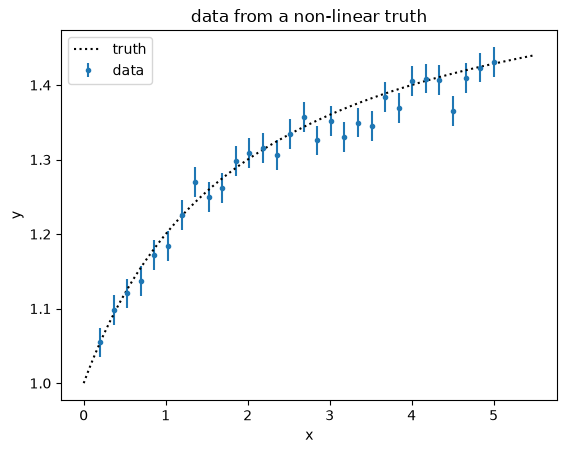

In [3]:
# truth: a saturating (non-linear) curve the straight line cannot capture
K = 2.0


def truth(x):
    return (0.8 * x + 1.0) / (1.0 + x / K)


x = np.linspace(0.2, 5.0, 30)
noise = 0.02
y = truth(x) + rng.normal(0.0, noise, size=x.size)
observation = rxmc.observation.Observation(x=x, y=y, y_stat_err=noise * np.ones_like(y))

xg = np.linspace(0.0, 5.5, 120)  # fine grid for predictions

plt.errorbar(x, y, noise, ls="none", marker=".", label="data")
plt.plot(xg, truth(xg), "k:", label="truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("data from a non-linear truth");

## Building the constraint with a GP discrepancy term

`rxmc.covariance.discrepancy_term(support, kernel)` wraps a scikit-learn kernel as
a `KernelTerm`. It **auto-derives one `Parameter` per free kernel hyperparameter**
(sampled in sklearn's log-theta space). The constraint then carries those
hyperparameters as its covariance parameters (`constraint.params`), so it is
auto-detected as a parametric constraint.

In [4]:
kernel = ConstantKernel(1.0) * Matern(length_scale=2.0, nu=2.5) + WhiteKernel(1e-6)
(support,) = rxmc.covariance.stacked_supports([observation])

constraint_gp = rxmc.constraint.Constraint(
    [observation],
    model,
    extra_terms=[rxmc.covariance.discrepancy_term(support, kernel)],
)
evidence_gp = rxmc.evidence.Evidence([constraint_gp])

print("GP hyperparameters (sampled in log-theta space):")
for p in constraint_gp.params:
    print("   ", p.name)

GP hyperparameters (sampled in log-theta space):
    discrepancy_k1__k1__constant_value
    discrepancy_k1__k2__length_scale
    discrepancy_k2__noise_level


For comparison we also build two reference constraints over the *same* data:
a plain line (statistical errors only) and a line with an uncorrelated
**model-error** term (`model_error_term`, the diagonal $\gamma^2$ inflation).
Neither can represent the *correlated* curvature the GP captures.

In [5]:
constraint_plain = rxmc.constraint.Constraint([observation], model)
evidence_plain = rxmc.evidence.Evidence([constraint_plain])

gamma = rxmc.params.Parameter(
    "log fractional err", float, latex_name=r"\gamma", unit="dimensionless"
)
constraint_me = rxmc.constraint.Constraint(
    [observation],
    model,
    extra_terms=[rxmc.covariance.model_error_term(support, gamma, averaging=True)],
)
evidence_me = rxmc.evidence.Evidence([constraint_me])

## Sampling

The physical parameters $(m, b)$ are sampled in the model block; each parametric
constraint's covariance parameters (GP log-theta, or $\gamma$) are sampled in a
Gibbs block by a `likelihood_sampler`. GP hyperparameters get a broad
$\mathcal N(0, 2)$ prior **per log-hyperparameter**.

In [6]:
model_prior = stats.multivariate_normal(mean=[0.8, 1.0], cov=np.diag([0.5, 0.5]) ** 2)


def make_model_sampler():
    return rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=model.params,
        starting_location=model_prior.mean,
        prior=model_prior,
        initial_proposal_cov=model_prior.cov / 100,
    )


def make_nuisance_sampler(params, prior, cov):
    return rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=list(params),
        starting_location=prior.mean,
        prior=prior,
        initial_proposal_cov=cov,
    )


theta_prior = stats.multivariate_normal(
    mean=np.zeros(constraint_gp.n_params), cov=4.0 * np.eye(constraint_gp.n_params)
)
gamma_prior = stats.multivariate_normal(mean=[np.log(0.05)], cov=[[1.0]])

walkers = {}
walkers["line only"] = rxmc.walker.Walker(make_model_sampler(), evidence_plain, rng=rng)
walkers["line + model error"] = rxmc.walker.Walker(
    make_model_sampler(),
    evidence_me,
    likelihood_samplers=[
        make_nuisance_sampler(constraint_me.params, gamma_prior, np.array([[0.04]]))
    ],
    rng=rng,
)
walkers["line + GP discrepancy"] = rxmc.walker.Walker(
    make_model_sampler(),
    evidence_gp,
    likelihood_samplers=[
        make_nuisance_sampler(
            constraint_gp.params, theta_prior, 0.04 * np.eye(constraint_gp.n_params)
        )
    ],
    rng=rng,
)

for key, walker in walkers.items():
    walker.walk(n_steps=4000, burnin=1500, batch_size=500, verbose=False)
    print(
        f"{key}: model acceptance "
        f"{walker.model_sampler.overall_acceptance_fraction():.2f}"
    )

line only: model acceptance 0.45


line + model error: model acceptance 0.35


line + GP discrepancy: model acceptance 0.38


## Posterior of the GP hyperparameters

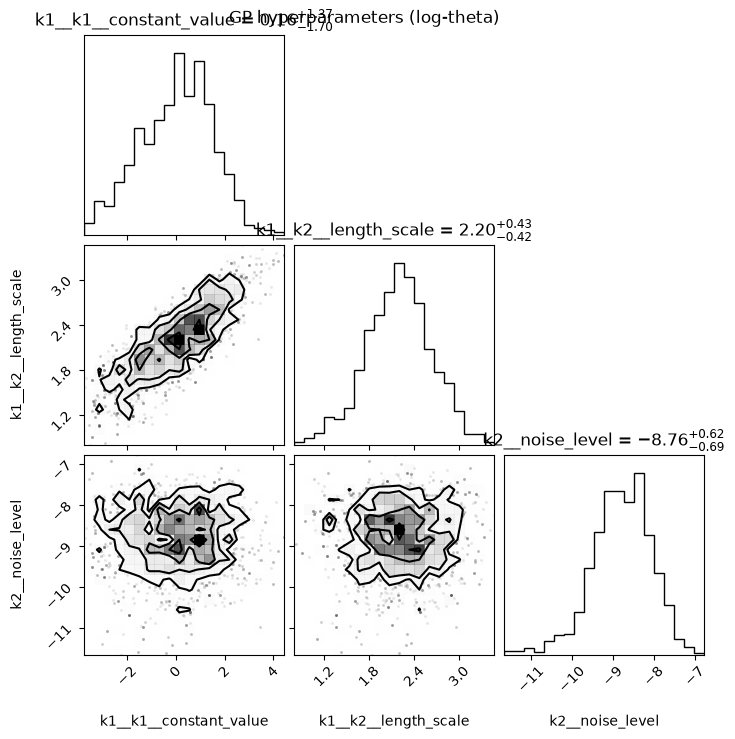

In [7]:
gp_walker = walkers["line + GP discrepancy"]
theta_chain = gp_walker.likelihood_samplers[0].chain
fig = corner.corner(
    theta_chain,
    labels=[p.latex_name for p in constraint_gp.params],
    show_titles=True,
)
fig.suptitle("GP hyperparameters (log-theta)");

## Propagating the total uncertainty

`rxmc.predictive.total_predictive_band` takes the posterior draws
$[m, b \mid \log\theta]$ and, for each draw, conditions the GP discrepancy on the
residuals and samples
$y_* = y_m(x_*) + \bar f_*(x_*) + \mathcal N(0,\ \mathrm{var}_* + \sigma^2)$ on the
fine grid. The line-only and model-error bands are credible intervals on the mean
line (they cannot bend); the GP band tracks the non-linear truth.

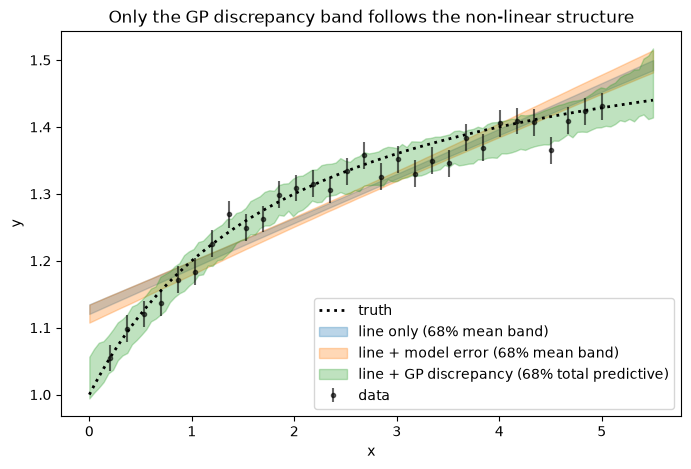

In [8]:
draws_gp = np.column_stack([gp_walker.model_sampler.chain, theta_chain])

band_gp = rxmc.predictive.total_predictive_band(
    model.y,
    kernel,
    x,
    y,
    xg,
    draws_gp,
    n_model_params=model.n_params,
    noise_std=noise,
    levels=(16, 84),
    n_draws=300,
    rng=rng,
)


def mean_line_band(walker, levels=(16, 84)):
    chain = walker.model_sampler.chain[:, : model.n_params]
    return rxmc.predictive.predictive_band(
        np.array([model.y(xg, *p) for p in chain]), levels=levels
    )


band_plain = mean_line_band(walkers["line only"])
band_me = mean_line_band(walkers["line + model error"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xg, truth(xg), "k:", lw=2, label="truth")
ax.errorbar(x, y, noise, ls="none", marker=".", color="k", alpha=0.6, label="data")
for (lo, hi), c, lab in [
    (band_plain, "tab:blue", "line only (68% mean band)"),
    (band_me, "tab:orange", "line + model error (68% mean band)"),
    (band_gp, "tab:green", "line + GP discrepancy (68% total predictive)"),
]:
    ax.fill_between(xg, lo, hi, color=c, alpha=0.3, label=lab)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Only the GP discrepancy band follows the non-linear structure");

## What the GP actually captured: the correlated residuals

The smoking gun for model discrepancy is **structure in the residuals** $y -
y_m(x)$ — a good (well-specified) model leaves white noise. Conditioning the GP on
those residuals (`rxmc.predictive.gp_posterior_predictive`) recovers a smooth
discrepancy that matches the true mismatch `truth(x) - line(x)`.

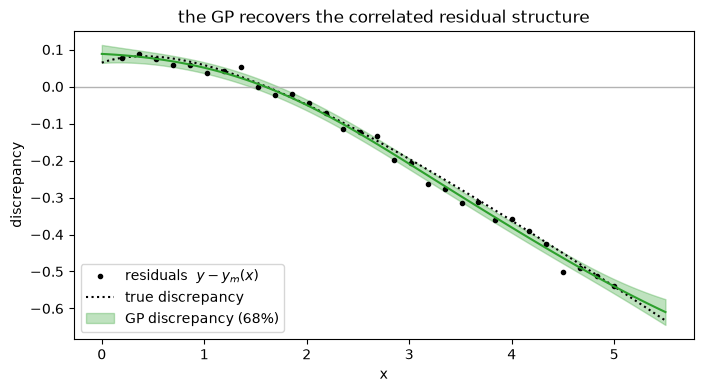

In [9]:
mp_mean = gp_walker.model_sampler.chain.mean(axis=0)
theta_mean = theta_chain.mean(axis=0)
residuals = y - model.y(x, *mp_mean)

disc_mean, disc_cov = rxmc.predictive.gp_posterior_predictive(
    kernel, theta_mean, x, residuals, xg, train_noise_var=noise**2
)
disc_sd = np.sqrt(np.clip(np.diag(disc_cov), 0.0, np.inf))

plt.figure(figsize=(8, 4))
plt.axhline(0.0, color="0.7", lw=1)
plt.plot(x, residuals, "k.", label="residuals  $y - y_m(x)$")
plt.plot(xg, truth(xg) - model.y(xg, *mp_mean), "k:", label="true discrepancy")
plt.fill_between(
    xg,
    disc_mean - disc_sd,
    disc_mean + disc_sd,
    color="tab:green",
    alpha=0.3,
    label="GP discrepancy (68%)",
)
plt.plot(xg, disc_mean, color="tab:green")
plt.xlabel("x")
plt.ylabel("discrepancy")
plt.legend()
plt.title("the GP recovers the correlated residual structure");

## Takeaways

- A GP discrepancy is **just another covariance `Term`** — `discrepancy_term`
  (a `KernelTerm`) added to the constraint. Its hyperparameters become
  constraint parameters and are sampled like any other nuisance.
- The `KernelTerm` only inflates the covariance at the data points. To predict the
  discrepancy at new $x$, use `rxmc.predictive.gp_posterior_predictive`; to get a
  full data-space band that propagates model, discrepancy, and noise uncertainty,
  use `rxmc.predictive.total_predictive_band`.
- Uncorrelated model error (`model_error_term`) inflates the variance but cannot
  represent correlated mis-modelling; the GP can.

# GP discrepancy on a differential cross section

The same machinery on real reaction physics: we generate mock
$n + {}^{40}$Ca elastic scattering data from a **full** optical potential
(volume + surface absorption), then fit it with a **deficient** potential that
has no surface term.  The missing physics leaves a smooth, *angle-correlated*
residual — exactly what a `discrepancy_term` over the angle grid absorbs.


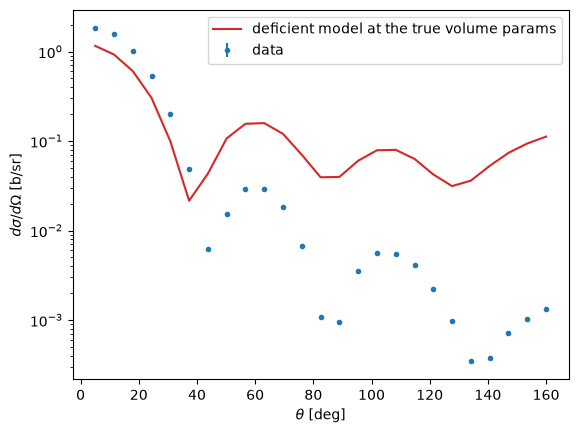

In [10]:
import jitr
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)

from rxmc.params import Parameter

Ca40 = (40, 20)
E_lab = 14.1
rxn = jitr.reactions.ElasticReaction(target=Ca40, projectile=(1, 0))
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION
R40 = 1.2 * 40 ** (1 / 3)
fixed_spin_orbit = (6.0, -3, R40, 0.45)


def full_central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) + (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


def volume_central(r, Vv, Wv, Rv, av):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av)


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)


omp_full = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=full_central,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=lambda ws, *x: (tuple(x), fixed_spin_orbit),
    params=[
        Parameter(n, unit=u)
        for n, u in [
            ("Vv", "MeV"),
            ("Wv", "MeV"),
            ("Rv", "fm"),
            ("av", "fm"),
            ("Wd", "MeV"),
            ("Rd", "fm"),
            ("ad", "fm"),
        ]
    ],
    model_name="full_potential",
)
omp_vol = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=volume_central,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=lambda ws, *x: (tuple(x), fixed_spin_orbit),
    params=[
        Parameter(n, unit=u)
        for n, u in [("Vv", "MeV"), ("Wv", "MeV"), ("Rv", "fm"), ("av", "fm")]
    ],
    model_name="volume_only_potential",
)

full_truth = np.array([48.0, 3.5, 1.1 * 40 ** (1 / 3), 0.7, 21, R40, 0.5])
volume_truth = full_truth[:4]  # the deficient model's share of the truth

obs_xs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=np.linspace(5.0, 160.0, 25),
    y=np.ones(25),
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    dataset_label="mock elastic dataset",
)
y_true_xs = omp_full.evaluate(obs_xs, *full_truth)
stat_xs = 0.04 * np.maximum(y_true_xs, 1e-4)
obs_xs.y = np.clip(y_true_xs + rng.normal(scale=stat_xs), 1e-6, None)
obs_xs.y_stat_err = stat_xs

plt.errorbar(
    np.rad2deg(obs_xs.x), obs_xs.y, stat_xs, ls="none", marker=".", label="data"
)
plt.plot(
    np.rad2deg(obs_xs.x),
    omp_vol.evaluate(obs_xs, *volume_truth),
    "tab:red",
    label="deficient model at the true volume params",
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [b/sr]")
plt.yscale("log")
plt.legend();

## The discrepancy term acts on the angle grid

The kernel's input coordinate is `obs.x` — the scattering angle **in radians**
— so the `length_scale` is an angular correlation length.  Everything else is
identical to the toy section.


In [11]:
kernel_xs = ConstantKernel(1.0) * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(1e-6)
(support_xs,) = rxmc.covariance.stacked_supports([obs_xs])

c_vol_plain = rxmc.constraint.Constraint([obs_xs], omp_vol)
c_vol_gp = rxmc.constraint.Constraint(
    [obs_xs],
    omp_vol,
    extra_terms=[rxmc.covariance.discrepancy_term(support_xs, kernel_xs)],
)
print("GP hyperparameters:", [p.name for p in c_vol_gp.params])

GP hyperparameters: ['discrepancy_k1__k1__constant_value', 'discrepancy_k1__k2__length_scale', 'discrepancy_k2__noise_level']


In [12]:
%%time
vol_prior = stats.multivariate_normal(
    mean=np.array([50.0, 3.0, 1.2 * 40 ** (1 / 3), 0.65]),
    cov=np.diag([7.0, 7.0, 0.2, 0.2]) ** 2,
)


def make_vol_sampler():
    return rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=omp_vol.params,
        starting_location=vol_prior.mean,
        prior=vol_prior,
        initial_proposal_cov=vol_prior.cov / 100,
    )


theta_prior_xs = stats.multivariate_normal(
    mean=np.zeros(c_vol_gp.n_params), cov=4.0 * np.eye(c_vol_gp.n_params)
)

walker_vol_plain = rxmc.walker.Walker(
    make_vol_sampler(), rxmc.evidence.Evidence([c_vol_plain]), rng=rng
)
walker_vol_gp = rxmc.walker.Walker(
    make_vol_sampler(),
    rxmc.evidence.Evidence([c_vol_gp]),
    likelihood_samplers=[
        make_nuisance_sampler(
            c_vol_gp.params, theta_prior_xs, 0.04 * np.eye(c_vol_gp.n_params)
        )
    ],
    rng=rng,
)
for w in (walker_vol_plain, walker_vol_gp):
    w.walk(n_steps=5000, burnin=1500, batch_size=500, verbose=False)

CPU times: user 33.9 s, sys: 2.23 ms, total: 33.9 s
Wall time: 33.9 s


no discrepancy    Vv=32.20±1.17  Wv=22.95±0.67  Rv=4.28±0.05  av=0.66±0.01
GP discrepancy    Vv=44.56±2.89  Wv=17.74±1.27  Rv=4.17±0.14  av=0.60±0.05
truth            Vv=48.00  Wv=3.50  Rv=3.76  av=0.70


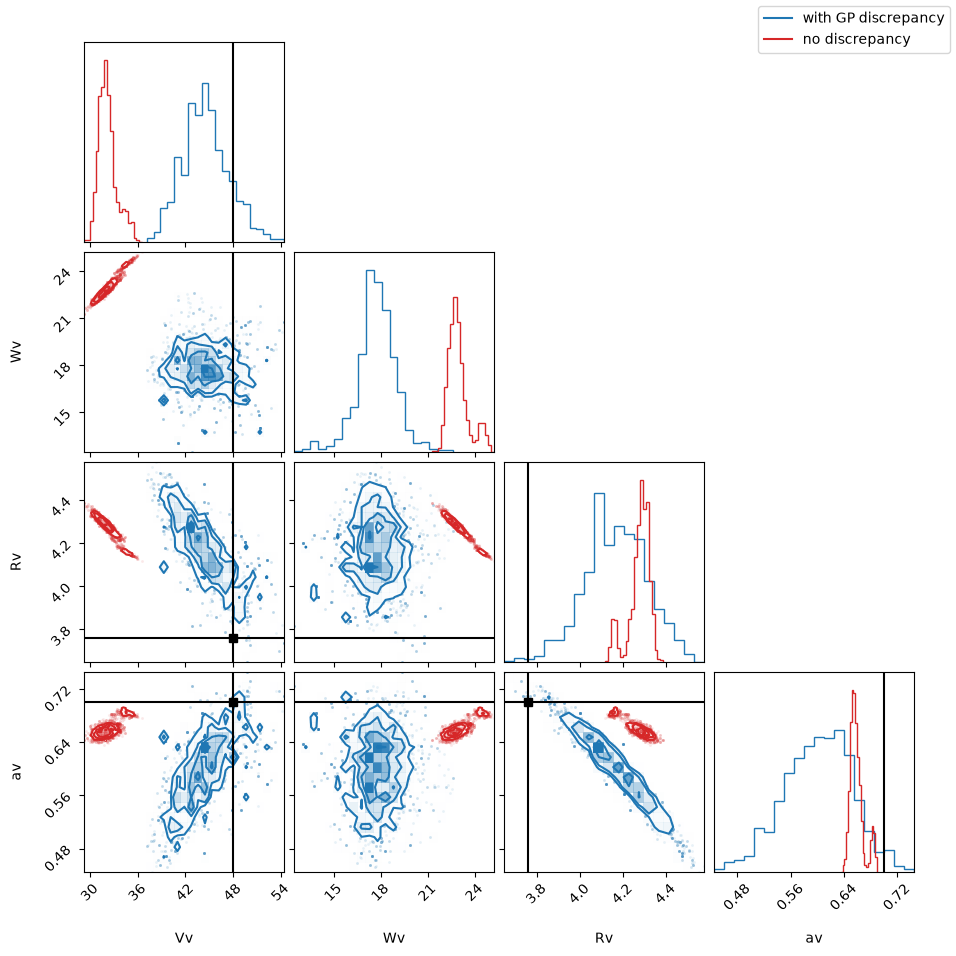

In [13]:
for name, w in [
    ("no discrepancy", walker_vol_plain),
    ("GP discrepancy", walker_vol_gp),
]:
    ch = w.model_sampler.chain
    print(
        f"{name:16s}  "
        + "  ".join(
            f"{p.name}={ch[:, i].mean():.2f}±{ch[:, i].std():.2f}"
            for i, p in enumerate(omp_vol.params)
        )
    )
print(
    "truth            "
    + "  ".join(f"{p.name}={v:.2f}" for p, v in zip(omp_vol.params, volume_truth))
)

fig = corner.corner(
    walker_vol_gp.model_sampler.chain,
    labels=[p.name for p in omp_vol.params],
    truths=volume_truth,
    truth_color="k",
    color="tab:blue",
)
corner.corner(walker_vol_plain.model_sampler.chain, fig=fig, color="tab:red")
plt.plot([], [], color="tab:blue", label="with GP discrepancy")
plt.plot([], [], color="tab:red", label="no discrepancy")
fig.legend(loc="upper right");

## The learned discrepancy vs the missing physics

Conditioning the GP on the posterior-mean residuals
(`rxmc.predictive.gp_posterior_predictive`) recovers the smooth angular
structure the deficient model cannot produce — compare it with the *true*
defect, the difference between the full and volume-only potentials.


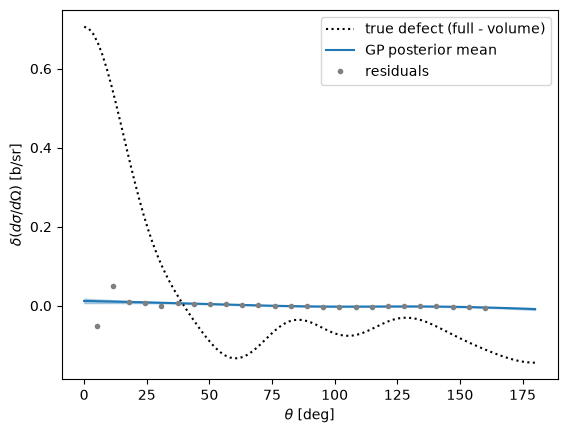

In [14]:
mp_vol = walker_vol_gp.model_sampler.chain.mean(axis=0)
theta_xs = walker_vol_gp.likelihood_samplers[0].chain.mean(axis=0)
residuals_xs = obs_xs.y - omp_vol.evaluate(obs_xs, *mp_vol)

angles_vis_rad = obs_xs.visualization_workspace.angles
disc_mean, disc_cov = rxmc.predictive.gp_posterior_predictive(
    kernel_xs,
    theta_xs,
    obs_xs.x,
    residuals_xs,
    angles_vis_rad,
    train_noise_var=obs_xs.y_stat_err**2,
)

true_defect = omp_full.visualizable_model_prediction(
    obs_xs, *full_truth
) - omp_vol.visualizable_model_prediction(obs_xs, *volume_truth)

angles_vis_deg = np.rad2deg(angles_vis_rad)
disc_std = np.sqrt(np.diag(disc_cov))
plt.plot(angles_vis_deg, true_defect, "k:", label="true defect (full - volume)")
plt.plot(angles_vis_deg, disc_mean, color="tab:blue", label="GP posterior mean")
plt.fill_between(
    angles_vis_deg,
    disc_mean - disc_std,
    disc_mean + disc_std,
    alpha=0.3,
    color="tab:blue",
)
plt.plot(np.rad2deg(obs_xs.x), residuals_xs, ".", color="gray", label="residuals")
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\delta(d\sigma/d\Omega)$ [b/sr]")
plt.legend();

## Takeaways, continued

- **Same API, real physics**: `discrepancy_term(support, kernel)` on a
  differential cross section works exactly as in the toy — the kernel just
  acts on the angle grid (radians), so its length scale is angular.
- Without the discrepancy term the deficient potential's parameters must
  contort to mimic the missing surface absorption (note $V_v$ lands many
  $\sigma$ from the truth, and $W_v$ inflates to play the role of $W_d$);
  with it, the GP absorbs the angle-correlated defect and the geometry
  parameters relax to the truth.  $W_v$ remains partially biased — volume and
  surface absorption are genuinely degenerate at one energy, and no
  discrepancy model can restore information the data do not contain.
- `rxmc.predictive.gp_posterior_predictive` reconstructs the learned
  discrepancy on any angle grid — useful for comparing against candidate
  missing-physics terms.
